# Global LSTM vs two Chronos-2 sweeps on the anomaly benchmark, one $\mathtt{H}$ each

Reads `results/<GLOBAL_RUN>/seed*/ts*/summary.json` (upstream's global LSTM,
fine-tuned per series) and, for each LLM sweep in `LLM_RUNS`,
`results/<sweep>/H<H>/ts*/summary.json` at the one re-forecast interval chosen for it.
The two Chronos-2 sweeps differ only in `zero_llm_variance` and
`feed_observed_residual`. All three ran on the same series and the same synthetic
realizations (`scripts/check_same_inputs.py`), so the comparison is paired. Only
series finished in **every** run are used, and only magnitudes present in every run.

Aggregation across series is **macro**, as in `plot_results.ipynb`: each series first
gets its own metric, then all series count equally. With several seeds, a series'
LSTM metric is first averaged over its seeds, so every series still counts once.
Plots show the median over series (line) with its IQR (band), one color per condition.

- Time to detection is undefined for a series that detected nothing at a slope, so
  those series are left out of that point's statistics.
- False alarms come from the clean series, so each case has one rate that does not
  depend on slope. Upstream counts them per time step, not per alarm episode.

In [9]:
import json
import textwrap
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GLOBAL_RUN = "full_global_finetune"
# LLM sweep -> (legend name, the H plotted for it). By mean over slopes of the median
# score, full_chronos2_small is best at H=104 (0.19) and the zero-variance residual
# sweep at H=208 (0.39); at H=13 they reach 0.16 and 0.24.
LLM_RUNS = {
    "full_chronos2_small": ("Chronos-2 small", 104),
    "full_chronos2_small_zerovar_residual": ("Chronos-2 small, zero var., residual", 208),
}

RESULTS = Path("results")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
PREFIX = "_vs_".join([GLOBAL_RUN, *(f"{sweep}_H{h}" for sweep, (_, h) in LLM_RUNS.items())])

SINGLE_COL = (3.5, 2.5)
DOUBLE_COL = (6.5, 3.5)

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
    "pgf.preamble": r"\usepackage{amsfonts}\usepackage{amssymb}\usepackage{amsmath}",
    "lines.linewidth": 1,
    "figure.figsize": SINGLE_COL,
    "font.size": 9,
    "savefig.dpi": 300,
})

# Same size as plot_results.ipynb, so the two sets of figures sit side by side.
FIGSIZE = (5.0, SINGLE_COL[1])


def save(fig, name):
    for ext in ("pgf", "pdf", "svg"):
        fig.savefig(FIGURES_DIR / f"{PREFIX}_{name}.{ext}")

In [10]:
SCORE_HALF_LIFE = 0.2  # h, false alarms per year that halve the score (see below)
METRICS = ["probability_of_detection", "false_alarm_rate_per_y",
           "time_to_detection_years_mean", "score"]


def load(pattern, case_key):
    rows = []
    for path in sorted(RESULTS.glob(pattern)):
        summary = json.loads(path.read_text())
        for row in summary["multi_realization_evaluation"]:
            rows.append({"series": summary["series"], case_key: summary[case_key], **row})
    frame = pd.DataFrame(rows)
    # Per run, before any averaging: the score is not linear in its inputs.
    frame["score"] = frame["probability_of_detection"] * 2 ** (
        -frame["false_alarm_rate_per_y"] / SCORE_HALF_LIFE
    )
    return frame


LLM_LABELS = {sweep: rf"{name}, $\mathtt{{H}}={h}$" for sweep, (name, h) in LLM_RUNS.items()}
LSTM_LABEL = "Global LSTM, fine-tuned"
CONDITIONS = [*LLM_LABELS.values(), LSTM_LABEL]

runs = {
    LLM_LABELS[sweep]: load(f"{sweep}/H{h}/ts*/summary.json", "llm_horizon")
    for sweep, (_, h) in LLM_RUNS.items()
}
lstm_runs = load(f"{GLOBAL_RUN}/seed*/ts*/summary.json", "seed")
# One value per series: mean over seeds (NaN time to detection skipped).
runs[LSTM_LABEL] = lstm_runs.groupby(["series", "anomaly_magnitude"], as_index=False)[METRICS].mean()

series = sorted(set.intersection(*(set(run["series"]) for run in runs.values())))
slopes = sorted(set.intersection(*(set(run["anomaly_magnitude"]) for run in runs.values())))
frame = pd.concat([run.assign(condition=condition) for condition, run in runs.items()])
frame = frame[frame["series"].isin(series) & frame["anomaly_magnitude"].isin(slopes)]

missing = sorted(set().union(*(set(run["series"]) for run in runs.values())) - set(series))
print(f"{len(series)} paired series; missing from one run: {missing or 'none'}")
print(f"seeds per series (LSTM): {lstm_runs.groupby('series')['seed'].nunique().to_dict()}")
frame.groupby("condition")["series"].nunique().rename("num_series").to_frame().T

10 paired series; missing from one run: none
seeds per series (LSTM): {'ts25': 1, 'ts26': 1, 'ts27': 1, 'ts36': 1, 'ts57': 1, 'ts58': 1, 'ts61': 1, 'ts62': 1, 'ts66': 1, 'ts67': 1}


condition,"Chronos-2 small, $\mathtt{H}=104$","Chronos-2 small, zero var., residual, $\mathtt{H}=208$","Global LSTM, fine-tuned"
num_series,10,10,10


In [11]:
def across_series(frame, column, by):
    """Median and IQR over series, NaNs skipped."""

    grouped = frame.groupby(by)[column]
    return pd.DataFrame({
        "median": grouped.median(),
        "q25": grouped.quantile(0.25),
        "q75": grouped.quantile(0.75),
        "n": grouped.count(),
    })


COLORS = dict(zip(CONDITIONS, ["tab:blue", "tab:orange", "black"]))


def plot_vs_slope(column, ylabel):
    fig, ax = plt.subplots(figsize=FIGSIZE, layout="constrained")
    for condition in CONDITIONS:
        stats = across_series(frame[frame["condition"] == condition], column, "anomaly_magnitude")
        ax.fill_between(stats.index, stats["q25"], stats["q75"], color=COLORS[condition],
                        alpha=0.15, lw=0)
        ax.plot(stats.index, stats["median"], color=COLORS[condition], label=condition)
    # Log scale keeps spacing proportional while leaving room to label every tested magnitude.
    ax.set_xscale("log")
    ax.set_xticks(slopes)
    ax.set_xticklabels([f"{m:g}" for m in slopes])
    ax.minorticks_off()
    ax.set_xlabel(r"Anomaly magnitude (u/year)")
    ax.set_ylabel(ylabel)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
    return fig, ax


def by_condition(column):
    """Median over series, one row per condition, one column per slope."""

    table = across_series(frame, column, ["condition", "anomaly_magnitude"])
    return table["median"].unstack().loc[CONDITIONS].round(2)

## Probability of detection per slope

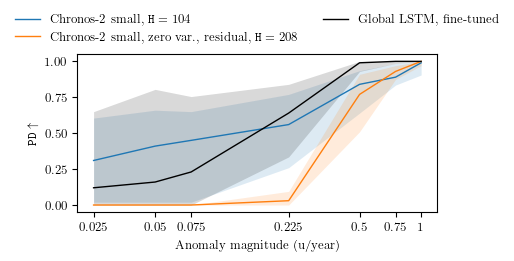

anomaly_magnitude,0.025,0.050,0.075,0.225,0.500,0.750,1.000
condition,,,,,,,
"Chronos-2 small, $\mathtt{H}=104$",0.31,0.41,0.45,0.56,0.84,0.89,0.99
"Chronos-2 small, zero var., residual, $\mathtt{H}=208$",0.00,0.00,0.00,0.03,0.77,0.93,1.00
"Global LSTM, fine-tuned",0.12,0.16,0.23,0.64,0.99,1.00,1.00


In [12]:
fig, ax = plot_vs_slope("probability_of_detection", r"\texttt{PD} $\uparrow$")
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
save(fig, "pod_vs_slope")
plt.show()

by_condition("probability_of_detection")

## Time to detection per slope

Per-series value is the mean time to detection over its detected realizations; `n` is
how many series detected at least once at that slope.

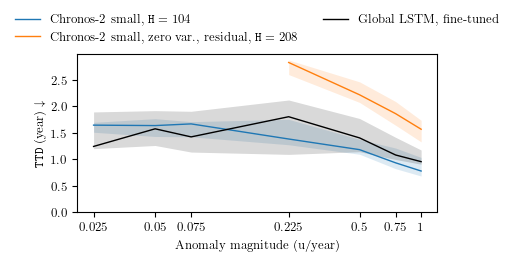

median                    \
anomaly_magnitude                                   0.025 0.050 0.075 0.225   
condition                                                                     
Chronos-2 small, $\mathtt{H}=104$                    1.65  1.64  1.67  1.38   
Chronos-2 small, zero var., residual, $\mathtt{...    NaN   NaN   NaN  2.83   
Global LSTM, fine-tuned                              1.24  1.58  1.42  1.81   

                                                                         n  \
anomaly_magnitude                                  0.500 0.750 1.000 0.025   
condition                                                                    
Chronos-2 small, $\mathtt{H}=104$                   1.18  0.93  0.78     7   
Chronos-2 small, zero var., residual, $\mathtt{...  2.22  1.86  1.57     0   
Global LSTM, fine-tuned                             1.40  1.08  0.96     5   

                                                                            \
anomaly_magnitude                                  0.050 0.075 0.225 0.500   
condition                                                                    
Chronos-2 small, $\mathtt{H}=104$                      7     7     8    10   
Chronos-2 small, zero var., residual, $\mathtt{...     0     0     5    10   
Global LSTM, fine-tuned                                6     6     9    10   

                                                                
anomaly_magnitude                                  0.750 1.000  
condition                                                       
Chronos-2 small, $\mathtt{H}=104$                     10    10  
Chronos-2 small, zero var., residual, $\mathtt{...    10    10  
Global LSTM, fine-tuned                               10    10

In [13]:
fig, ax = plot_vs_slope("time_to_detection_years_mean", r"\texttt{TTD} (year) $\downarrow$")
ax.set_ylim(bottom=0)
save(fig, "ttd_vs_slope")
plt.show()

ttd = across_series(frame, "time_to_detection_years_mean", ["condition", "anomaly_magnitude"])
ttd[["median", "n"]].unstack().loc[CONDITIONS].round(2)

## Detection score per slope

$\bar{S} = \mathcal{P}_{\mathrm{DET}} \cdot 2^{-\#_{\mathrm{ALM}}(y^{-1})/h}$ with $h = 0.2$:
each false alarm per year beyond $h$ halves the score again. Computed per series
(its own $\mathcal{P}_{\mathrm{DET}}$ at the slope and its own false alarm rate),
then aggregated across series like the other metrics.

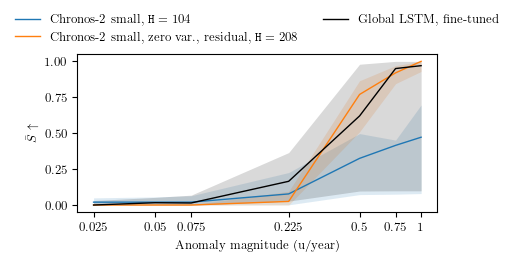

anomaly_magnitude,0.025,0.050,0.075,0.225,0.500,0.750,1.000
condition,,,,,,,
"Chronos-2 small, $\mathtt{H}=104$",0.02,0.02,0.02,0.08,0.32,0.42,0.47
"Chronos-2 small, zero var., residual, $\mathtt{H}=208$",0.00,0.00,0.00,0.03,0.77,0.92,1.00
"Global LSTM, fine-tuned",0.00,0.02,0.01,0.17,0.62,0.95,0.97


In [14]:
fig, ax = plot_vs_slope("score", r"$\bar{S}$ $\uparrow$")
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
save(fig, "score_vs_slope")
plt.show()

by_condition("score")

## False alarm rate per condition

One dot per series (jittered horizontally), IQR as a bar, median as a diamond. The
axis is logarithmic, so rates of zero are drawn at the floor `FA_FLOOR`.

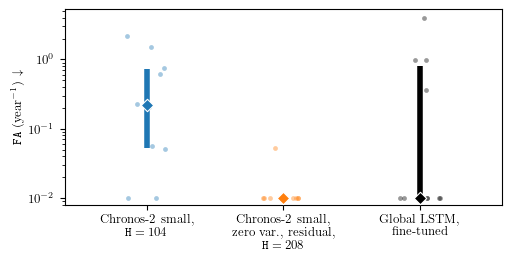

,median,q25,q75,n
condition,,,,
"Chronos-2 small, $\mathtt{H}=104$",0.217,0.052,0.718,10
"Chronos-2 small, zero var., residual, $\mathtt{H}=208$",0.000,0.000,0.000,10
"Global LSTM, fine-tuned",0.000,0.000,0.815,10


In [15]:
FA_FLOOR = 1e-2

false_alarms = (
    frame.groupby(["condition", "series"])["false_alarm_rate_per_y"].first().reset_index()
)
stats = across_series(false_alarms, "false_alarm_rate_per_y", "condition")
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=FIGSIZE, layout="constrained")
for x, condition in enumerate(CONDITIONS):
    color = COLORS[condition]
    values = false_alarms.loc[false_alarms["condition"] == condition, "false_alarm_rate_per_y"]
    jitter = rng.uniform(-0.15, 0.15, len(values))
    ax.scatter(x + jitter, np.maximum(values, FA_FLOOR), color=color, alpha=0.4, s=12, lw=0)
    ax.vlines(x, max(stats.loc[condition, "q25"], FA_FLOOR),
              max(stats.loc[condition, "q75"], FA_FLOOR), color=color, lw=4)
    ax.scatter(x, max(stats.loc[condition, "median"], FA_FLOOR), color=color, marker="D", s=40,
               edgecolor="white", lw=0.8, zorder=3)
ax.set_yscale("log")
ax.set_ylim(FA_FLOOR * 0.8, None)
ax.set_xlim(-0.6, len(CONDITIONS) - 0.4)
ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([textwrap.fill(condition, 20, break_on_hyphens=False) for condition in CONDITIONS])
ax.set_ylabel(r"\texttt{FA} (year$^{-1}$) $\downarrow$")
save(fig, "false_alarms")
plt.show()

stats.loc[CONDITIONS].round(3)

## Paired score difference per slope

Per series, LSTM score minus each LLM's score ($\bar{S}$ above), then the median over
series and how many series each side wins. Positive favors the global LSTM.

In [16]:
paired = frame.pivot_table(
    index=["series", "anomaly_magnitude"], columns="condition", values="score"
).dropna()
pd.concat({
    llm_label: (paired[LSTM_LABEL] - paired[llm_label]).groupby("anomaly_magnitude").agg(
        median_difference="median",
        lstm_better=lambda d: int((d > 0).sum()),
        llm_better=lambda d: int((d < 0).sum()),
        tied=lambda d: int((d == 0).sum()),
    )
    for llm_label in LLM_LABELS.values()
}, axis=1).round(2)

Chronos-2 small, $\mathtt{H}=104$                         \
                                  median_difference lstm_better llm_better   
anomaly_magnitude                                                            
0.025                                         -0.01           3          5   
0.050                                         -0.01           3          5   
0.075                                         -0.01           3          5   
0.225                                          0.06           6          4   
0.500                                          0.06           7          3   
0.750                                          0.12           7          3   
1.000                                          0.06           7          3   

                       Chronos-2 small, zero var., residual, $\mathtt{H}=208$  \
                  tied                                      median_difference   
anomaly_magnitude                                                               
0.025                2                                               0.00       
0.050                2                                               0.02       
0.075                2                                               0.01       
0.225                0                                               0.03       
0.500                0                                              -0.21       
0.750                0                                              -0.01       
1.000                0                                               0.00       

                                               
                  lstm_better llm_better tied  
anomaly_magnitude                              
0.025                       5          0    5  
0.050                       6          0    4  
0.075                       6          0    4  
0.225                       6          4    0  
0.500                       4          6    0  
0.750                       4          5    1  
1.000                       3          4    3